# Notebook 3 - Gráficos del TFM

Visualizaciones a partir de las tablas agregadas exportadas por el Notebook 2 (`data/tabla_*.parquet` y los datasets base).

## Carga de datos

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

catalogo_carteras = pd.read_parquet("data/entradas/catalogo_carteras.parquet")
dataset_colateral = pd.read_parquet("data/entradas/dataset_colateral.parquet")
dataset_montecarlo = pd.read_parquet("data/salidas/dataset_montecarlo.parquet")
dataset_financiacion = pd.read_parquet("data/salidas/dataset_financiacion.parquet")

comparativa_financiacion = pd.read_parquet("data/salidas/tabla_comparativa_financiacion.parquet")
df_resultados_ml = pd.read_parquet("data/salidas/tabla_resultados_ml_clasificacion.parquet")
df_resultados_regresion = pd.read_parquet("data/salidas/tabla_resultados_ml_regresion.parquet")
df_importancia_regresion = pd.read_parquet("data/salidas/tabla_importancia_variables_regresion.parquet")
df_predicciones_regresion = pd.read_parquet("data/salidas/tabla_predicciones_regresion.parquet")
mejores_carteras = pd.read_parquet("data/salidas/tabla_mejores_carteras.parquet")
resumen_optimizacion = pd.read_parquet("data/salidas/resumen_optimizacion.parquet")
frontera_optima = pd.read_parquet("data/salidas/tabla_frontera_optima.parquet")
riesgo_historico_perfil_21d = pd.read_parquet("data/salidas/tabla_riesgo_historico_perfil_21d.parquet")
mc_perfil = pd.read_parquet("data/salidas/tabla_montecarlo_perfil.parquet")
tabla_validaciones_finales = pd.read_parquet("data/salidas/tabla_validaciones_finales.parquet")

mejor_modelo_reg_nombre = df_resultados_regresion.sort_values("mae").iloc[0]["modelo"]

cols_pesos = ["w_XEON.DE", "w_SHY", "w_AGGU.L", "w_SPY"]
composicion_top = mejores_carteras.head(10)[["id_cartera", "tipo_financiacion"] + cols_pesos]

BLUE = "#4472C4"
ORANGE = "#ED7D31"

PALETTE = ["#4472C4", "#ED7D31", "#70AD47", "#FFC000", "#5B9BD5", "#A5A5A5", "#264478", "#9E480E"]


def etiquetar_barras(ax, fmt="{:.3f}", horizontal=False, fontsize=9):
    """Añade la etiqueta de valor sobre (o al lado, si es horizontal) cada barra."""
    for p in ax.patches:
        if horizontal:
            valor = p.get_width()
            y = p.get_y() + p.get_height() / 2
            ha = "left" if valor >= 0 else "right"
            ax.annotate(
                fmt.format(valor), (valor, y),
                xytext=(4 if valor >= 0 else -4, 0),
                textcoords="offset points", va="center", ha=ha, fontsize=fontsize
            )
        else:
            valor = p.get_height()
            x = p.get_x() + p.get_width() / 2
            va = "bottom" if valor >= 0 else "top"
            ax.annotate(
                fmt.format(valor), (x, valor),
                xytext=(0, 3 if valor >= 0 else -3),
                textcoords="offset points", ha="center", va=va, fontsize=fontsize
            )

print("Datos cargados correctamente.")


Datos cargados correctamente.


### Ilustración 1 - Distribución de carteras por perfil

,perfil,n_carteras
0,conservador,154
1,equilibrado,97
2,dinamico,35


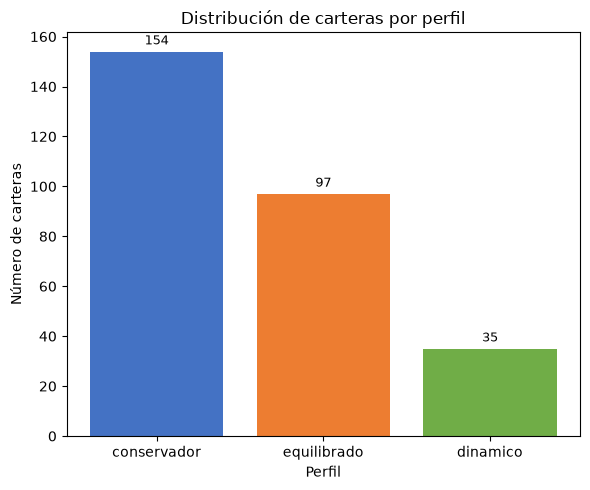

In [3]:
tabla_perfiles = (
    catalogo_carteras["perfil"]
    .value_counts()
    .rename_axis("perfil")
    .reset_index(name="n_carteras")
)

display(tabla_perfiles)

fig, ax = plt.subplots(figsize=(6, 5))
ax.bar(tabla_perfiles["perfil"], tabla_perfiles["n_carteras"], color=PALETTE[:len(tabla_perfiles)])
etiquetar_barras(ax, fmt="{:.0f}")
plt.title("Distribución de carteras por perfil")
plt.xlabel("Perfil")
plt.ylabel("Número de carteras")
plt.tight_layout()
plt.show()


### Evolución histórica del colateral por perfil

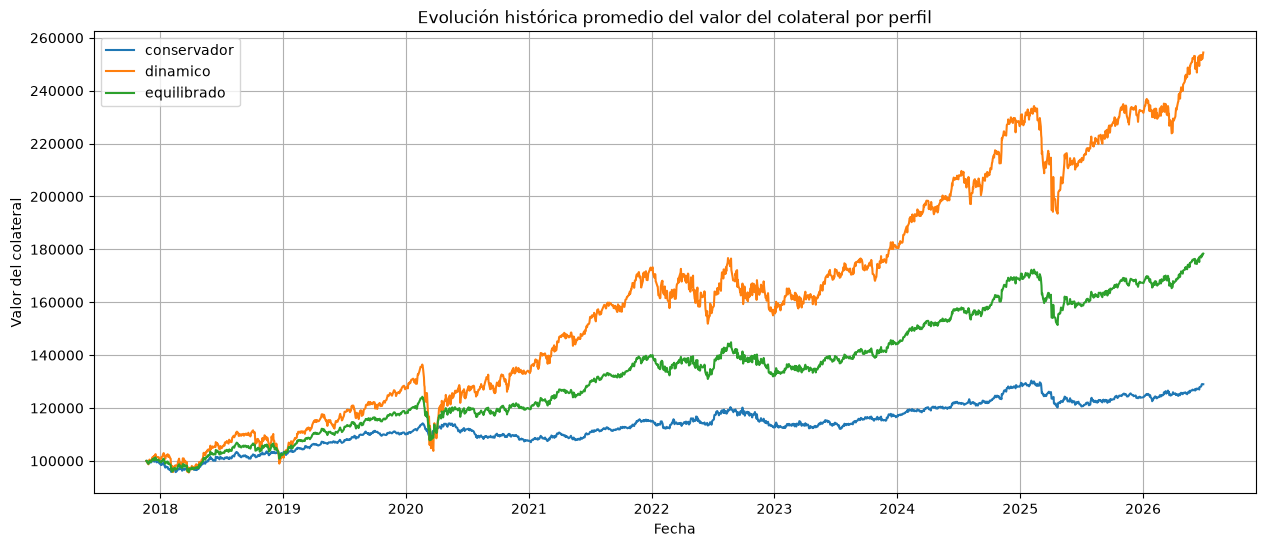

In [4]:
colateral_perfil = (
    dataset_colateral
    .groupby(["date", "perfil"])["valor_colateral"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(15, 6))

for perfil in colateral_perfil["perfil"].unique():
    temp = colateral_perfil[colateral_perfil["perfil"] == perfil]
    plt.plot(temp["date"], temp["valor_colateral"], label=perfil)

plt.title("Evolución histórica promedio del valor del colateral por perfil")
plt.xlabel("Fecha")
plt.ylabel("Valor del colateral")
plt.legend()
plt.grid(True)
plt.show()

### Distribución de retornos simulados a 3 años

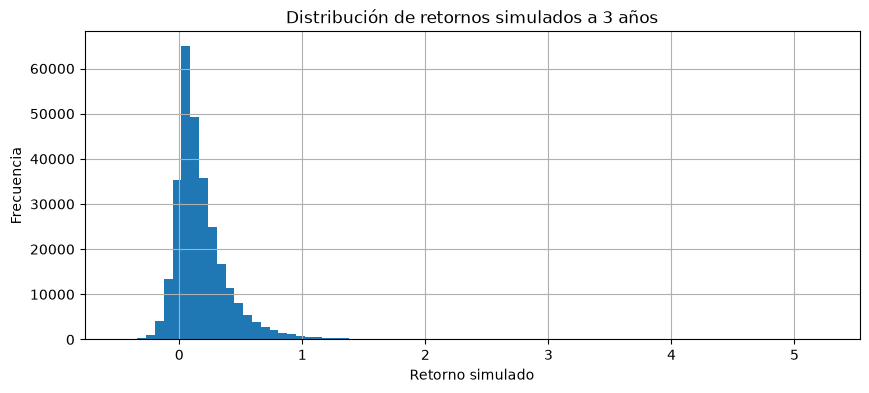

In [5]:
plt.figure(figsize=(10, 4))
plt.hist(dataset_montecarlo["retorno_simulado"], bins=80)
plt.title("Distribución de retornos simulados a 3 años")
plt.xlabel("Retorno simulado")
plt.ylabel("Frecuencia")
plt.grid(True)
plt.show()

### Distribución del LTV máximo aproximado

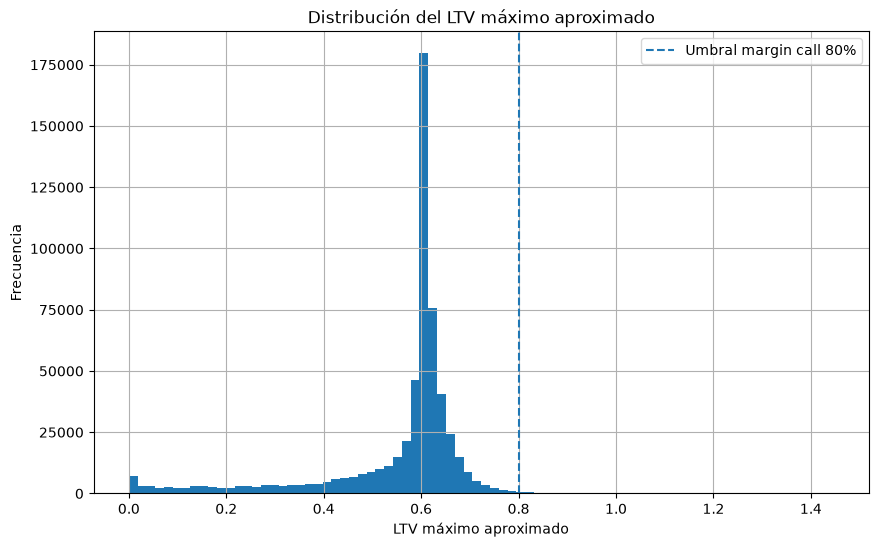

In [6]:
plt.figure(figsize=(10, 6))
plt.hist(dataset_financiacion["ltv_maximo_aproximado"], bins=80)
plt.axvline(0.80, linestyle="--", label="Umbral margin call 80%")
plt.title("Distribución del LTV máximo aproximado")
plt.xlabel("LTV máximo aproximado")
plt.ylabel("Frecuencia")
plt.legend()
plt.grid(True)
plt.show()

### Probabilidad de margin call por tipo de financiación

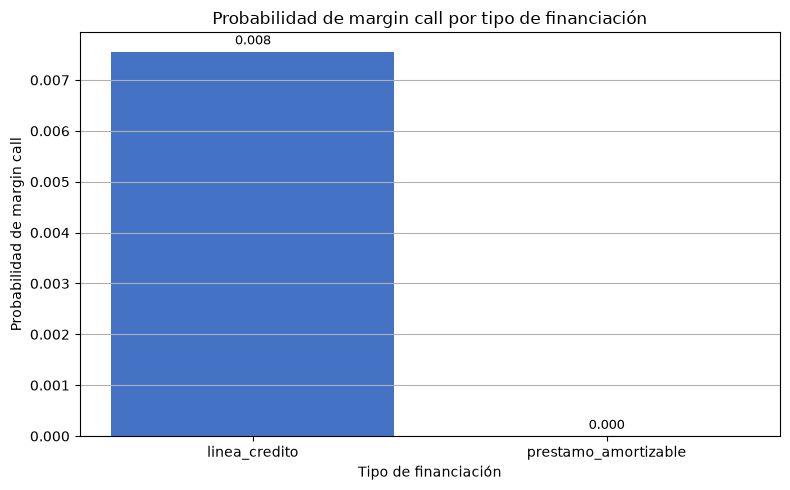

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(
    comparativa_financiacion["tipo_financiacion"],
    comparativa_financiacion["prob_margin_call"],
    color=PALETTE[:len(comparativa_financiacion)]
)
etiquetar_barras(ax, fmt="{:.3f}")
plt.title("Probabilidad de margin call por tipo de financiación")
plt.xlabel("Tipo de financiación")
plt.ylabel("Probabilidad de margin call")
plt.grid(axis="y")
plt.tight_layout()
plt.show()


### Comparación de modelos de clasificación por AUC-ROC

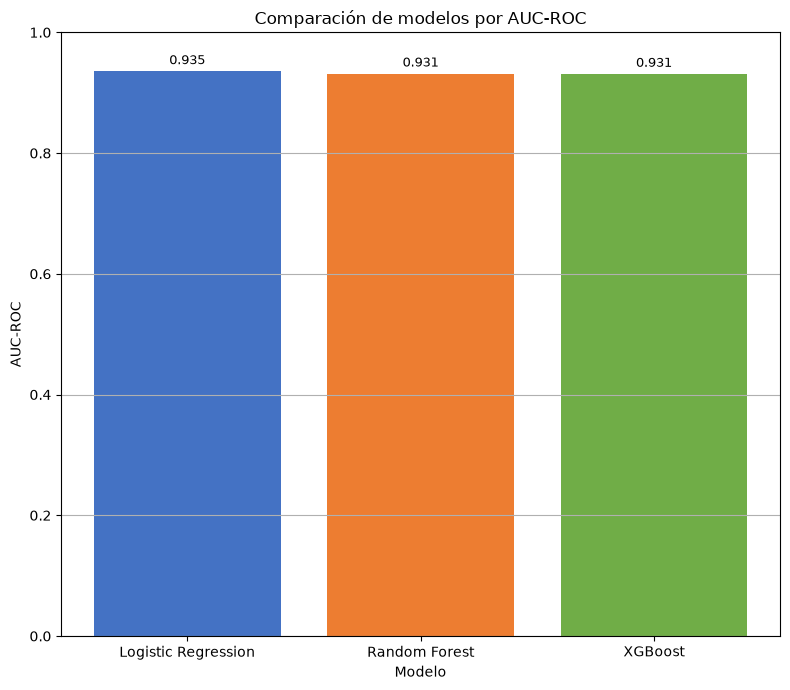

In [8]:
fig, ax = plt.subplots(figsize=(8, 7))
ax.bar(df_resultados_ml["modelo"], df_resultados_ml["auc_roc"], color=PALETTE[:len(df_resultados_ml)])
etiquetar_barras(ax, fmt="{:.3f}")
plt.title("Comparación de modelos por AUC-ROC")
plt.xlabel("Modelo")
plt.ylabel("AUC-ROC")
plt.ylim(0, 1)
plt.grid(axis="y")
plt.tight_layout()
plt.show()


### Comparación de modelos de clasificación por PR-AUC

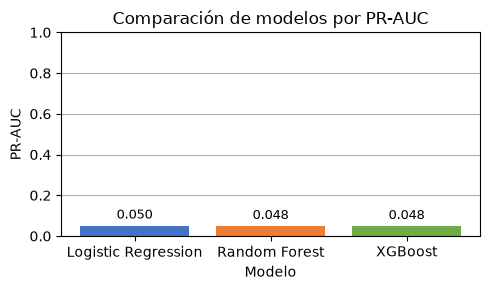

In [9]:
fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(df_resultados_ml["modelo"], df_resultados_ml["pr_auc"], color=PALETTE[:len(df_resultados_ml)])
etiquetar_barras(ax, fmt="{:.3f}")
plt.title("Comparación de modelos por PR-AUC")
plt.xlabel("Modelo")
plt.ylabel("PR-AUC")
plt.ylim(0, 1)
plt.grid(axis="y")
plt.tight_layout()
plt.show()


### Comparación de modelos de regresión por MAE

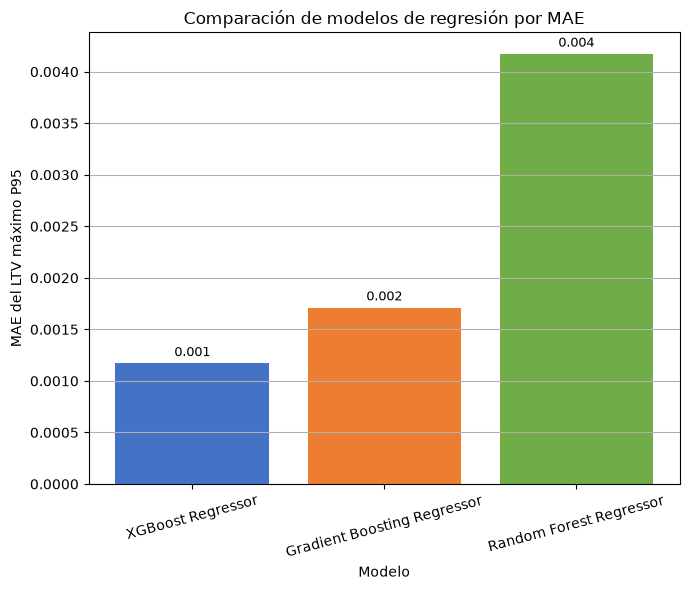

In [10]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.bar(df_resultados_regresion["modelo"], df_resultados_regresion["mae"], color=PALETTE[:len(df_resultados_regresion)])
etiquetar_barras(ax, fmt="{:.3f}")
plt.title("Comparación de modelos de regresión por MAE")
plt.xlabel("Modelo")
plt.ylabel("MAE del LTV máximo P95")
plt.xticks(rotation=15)
plt.grid(axis="y")
plt.tight_layout()
plt.show()


### Comparación de modelos de regresión por RMSE

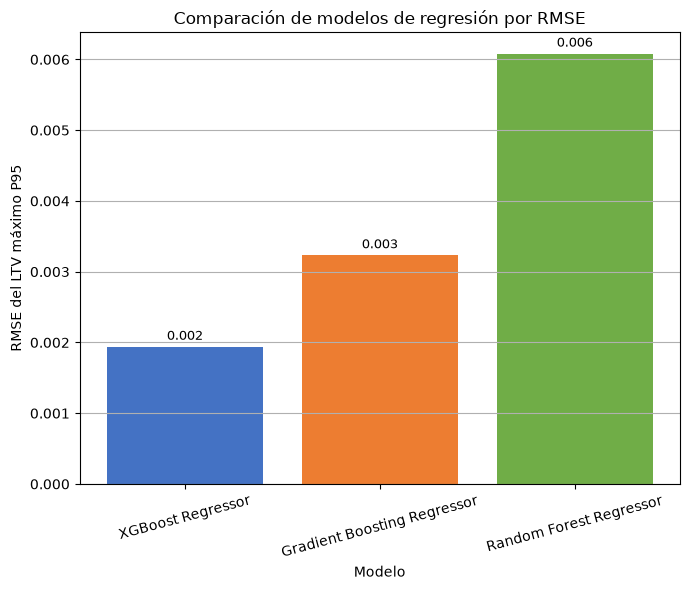

In [11]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.bar(df_resultados_regresion["modelo"], df_resultados_regresion["rmse"], color=PALETTE[:len(df_resultados_regresion)])
etiquetar_barras(ax, fmt="{:.3f}")
plt.title("Comparación de modelos de regresión por RMSE")
plt.xlabel("Modelo")
plt.ylabel("RMSE del LTV máximo P95")
plt.xticks(rotation=15)
plt.grid(axis="y")
plt.tight_layout()
plt.show()


### Comparación de modelos de regresión por R²

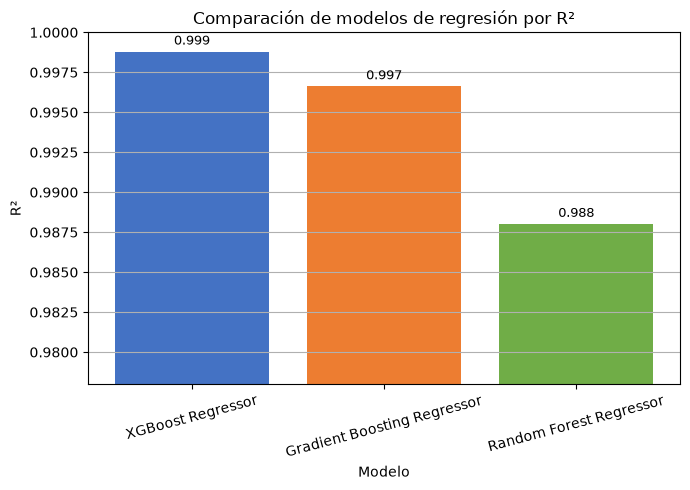

In [12]:
r2_min = max(0, df_resultados_regresion["r2"].min() - 0.01)

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(df_resultados_regresion["modelo"], df_resultados_regresion["r2"], color=PALETTE[:len(df_resultados_regresion)])
etiquetar_barras(ax, fmt="{:.3f}")
plt.title("Comparación de modelos de regresión por R²")
plt.xlabel("Modelo")
plt.ylabel("R²")
plt.ylim(r2_min, 1.0)
plt.xticks(rotation=15)
plt.grid(axis="y")
plt.tight_layout()
plt.show()


### Importancia de variables - modelo de regresión del LTV máximo P95

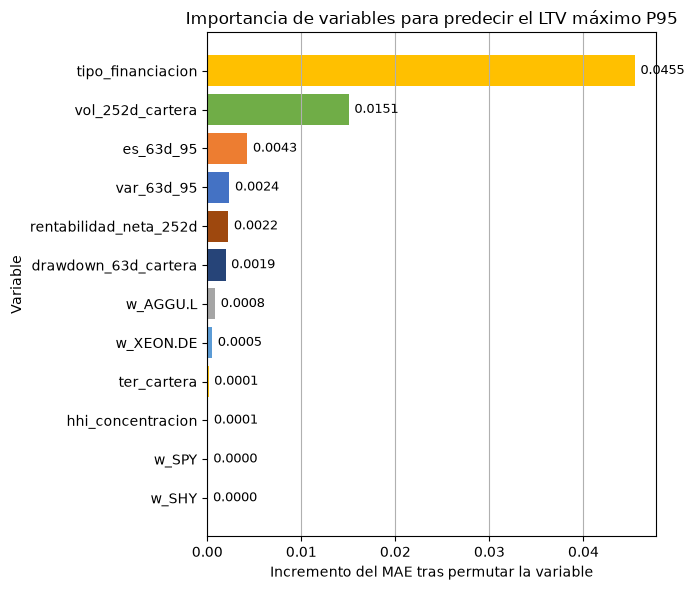

In [13]:
top_importancia = (
    df_importancia_regresion
    .head(12)
    .sort_values("importancia_media", ascending=True)
)

fig, ax = plt.subplots(figsize=(7, 6))
ax.barh(top_importancia["variable"], top_importancia["importancia_media"], color=PALETTE[:len(top_importancia)])
etiquetar_barras(ax, fmt="{:.4f}", horizontal=True)
plt.title("Importancia de variables para predecir el LTV máximo P95")
plt.xlabel("Incremento del MAE tras permutar la variable")
plt.ylabel("Variable")
plt.grid(axis="x")
plt.tight_layout()
plt.show()


### LTV máximo P95 real vs. predicho

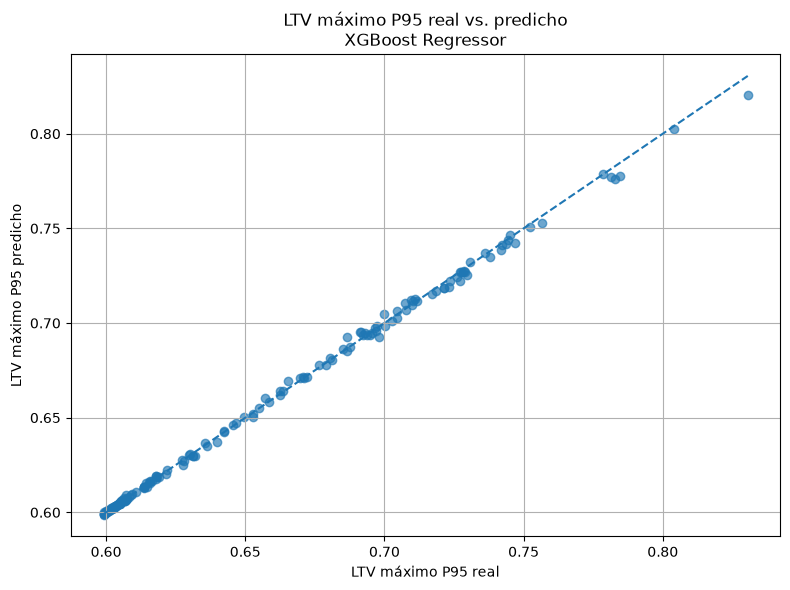

In [14]:
plt.figure(figsize=(8, 6))

plt.scatter(
    df_predicciones_regresion["ltv_real_p95"],
    df_predicciones_regresion["ltv_predicho_p95"],
    alpha=0.65
)

limite_min = min(
    df_predicciones_regresion["ltv_real_p95"].min(),
    df_predicciones_regresion["ltv_predicho_p95"].min()
)

limite_max = max(
    df_predicciones_regresion["ltv_real_p95"].max(),
    df_predicciones_regresion["ltv_predicho_p95"].max()
)

plt.plot(
    [limite_min, limite_max],
    [limite_min, limite_max],
    linestyle="--"
)

plt.title(
    f"LTV máximo P95 real vs. predicho\n"
    f"{mejor_modelo_reg_nombre}"
)

plt.xlabel("LTV máximo P95 real")
plt.ylabel("LTV máximo P95 predicho")
plt.grid(True)
plt.tight_layout()
plt.show()

### Residuos del modelo de regresión

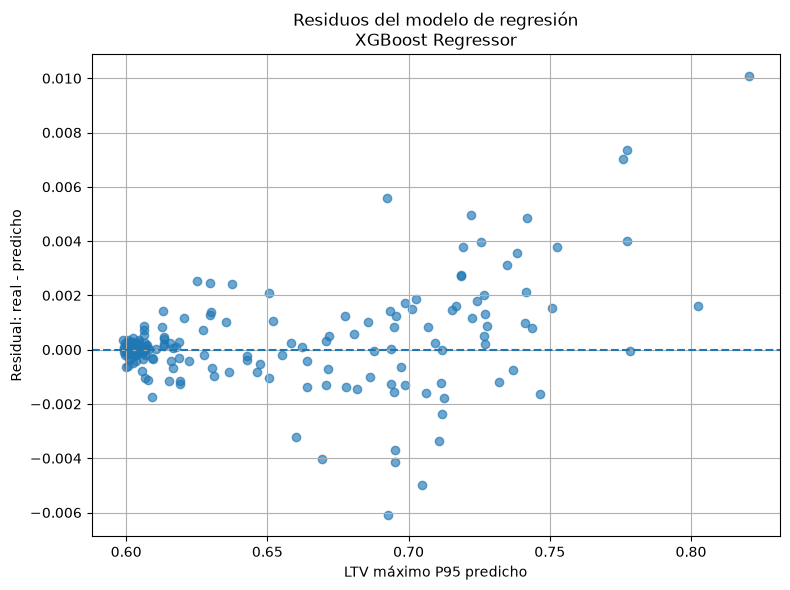

In [15]:
plt.figure(figsize=(8, 6))

plt.scatter(
    df_predicciones_regresion["ltv_predicho_p95"],
    df_predicciones_regresion["residuo"],
    alpha=0.65
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.title(
    f"Residuos del modelo de regresión\n"
    f"{mejor_modelo_reg_nombre}"
)

plt.xlabel("LTV máximo P95 predicho")
plt.ylabel("Residual: real - predicho")
plt.grid(True)
plt.tight_layout()
plt.show()

### Distribución del error absoluto del modelo

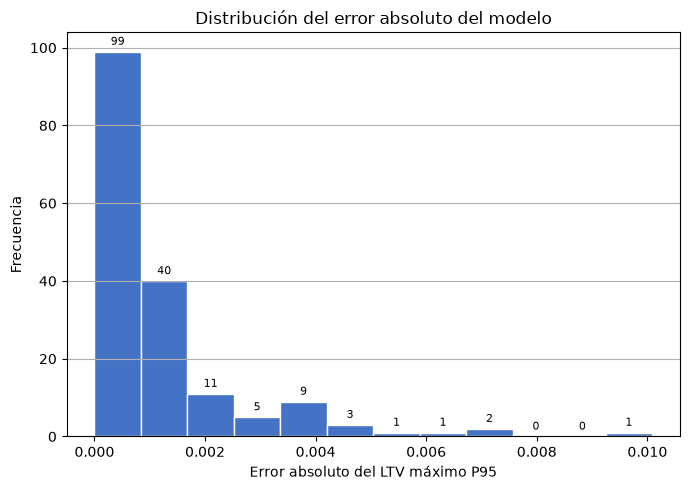

In [16]:
fig, ax = plt.subplots(figsize=(7, 5))

ax.hist(
    df_predicciones_regresion["error_absoluto"],
    bins=12,
    color=BLUE,
    edgecolor="white"
)
etiquetar_barras(ax, fmt="{:.0f}", fontsize=8)

plt.title("Distribución del error absoluto del modelo")
plt.xlabel("Error absoluto del LTV máximo P95")
plt.ylabel("Frecuencia")
plt.grid(axis="y")
plt.tight_layout()
plt.show()


### Ilustración 10 - Distribución de niveles de riesgo predicho

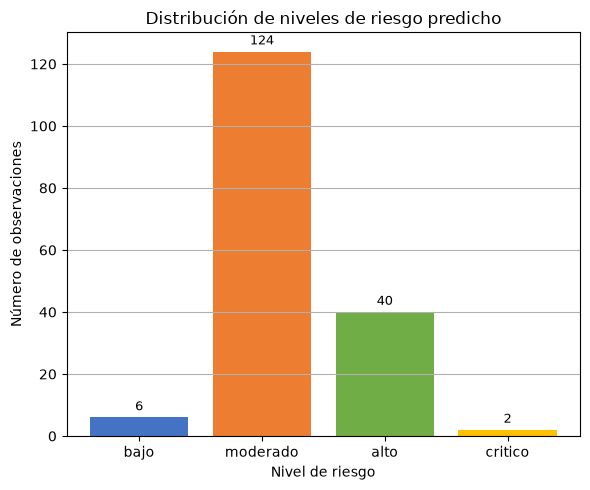

In [17]:
tabla_riesgo_predicho = (
    df_predicciones_regresion["riesgo_predicho"]
    .value_counts()
    .reindex(["bajo", "moderado", "alto", "critico"], fill_value=0)
    .rename_axis("nivel_riesgo")
    .reset_index(name="n_observaciones")
)

fig, ax = plt.subplots(figsize=(6, 5))
ax.bar(tabla_riesgo_predicho["nivel_riesgo"], tabla_riesgo_predicho["n_observaciones"], color=PALETTE[:len(tabla_riesgo_predicho)])
etiquetar_barras(ax, fmt="{:.0f}")
plt.title("Distribución de niveles de riesgo predicho")
plt.xlabel("Nivel de riesgo")
plt.ylabel("Número de observaciones")
plt.grid(axis="y")
plt.tight_layout()
plt.show()


### Top carteras por rentabilidad neta media

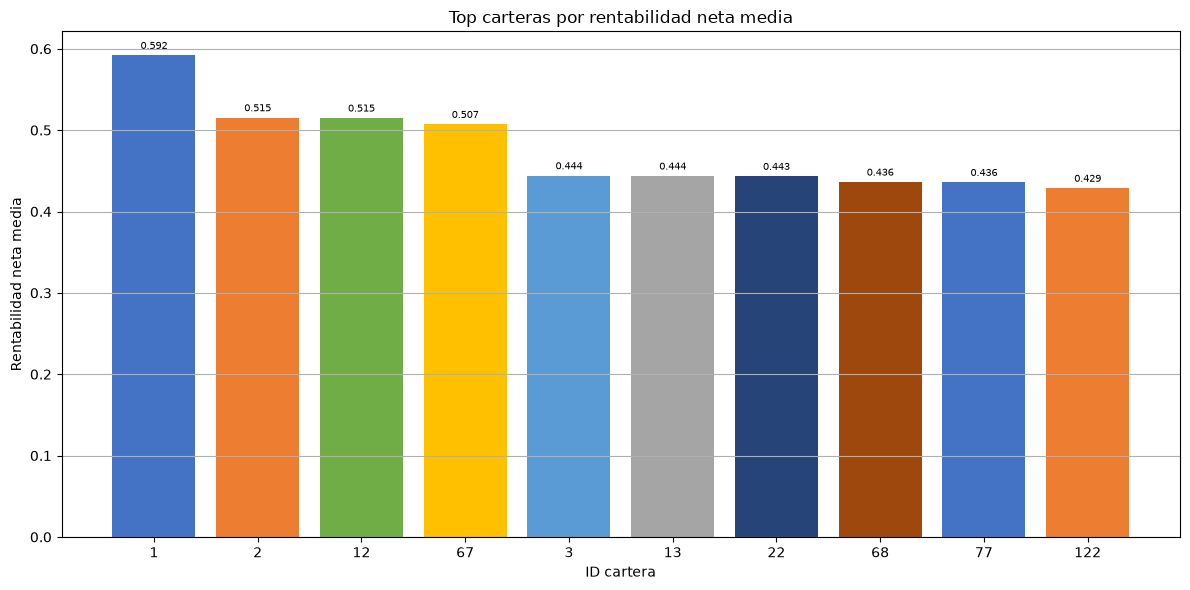

In [18]:
top_20 = mejores_carteras.head(20)
colores_top20 = [PALETTE[i % len(PALETTE)] for i in range(len(top_20))]

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(top_20["id_cartera"].astype(str), top_20["rentabilidad_neta_media"], color=colores_top20)
etiquetar_barras(ax, fmt="{:.3f}", fontsize=7)
plt.title("Top carteras por rentabilidad neta media")
plt.xlabel("ID cartera")
plt.ylabel("Rentabilidad neta media")
plt.grid(axis="y")
plt.tight_layout()
plt.show()


### Frontera riesgo-retorno bajo restricción de margin call

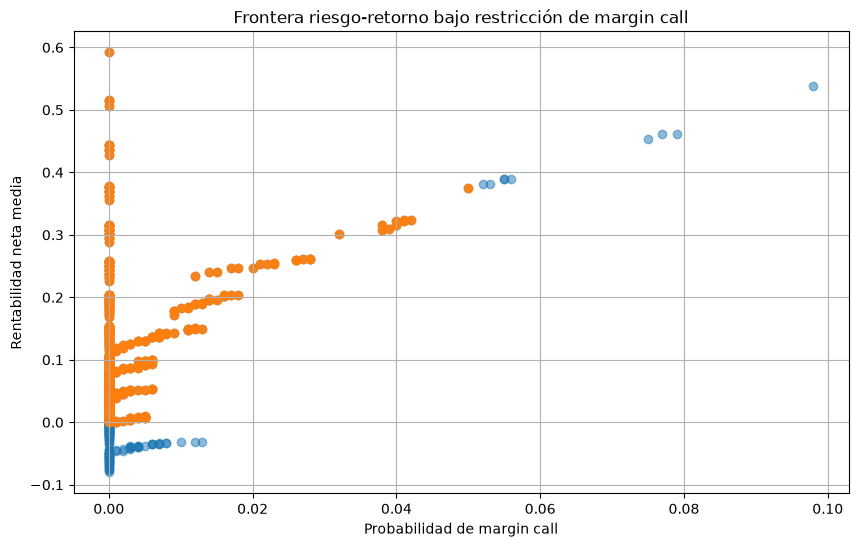

In [19]:
plt.figure(figsize=(10, 6))
plt.scatter(
    resumen_optimizacion["prob_margin_call"],
    resumen_optimizacion["rentabilidad_neta_media"],
    alpha=0.5
)

plt.scatter(
    frontera_optima["prob_margin_call"],
    frontera_optima["rentabilidad_neta_media"],
    alpha=0.9
)

plt.title("Frontera riesgo-retorno bajo restricción de margin call")
plt.xlabel("Probabilidad de margin call")
plt.ylabel("Rentabilidad neta media")
plt.grid(True)
plt.show()

### Rentabilidad neta media vs. drawdown medio

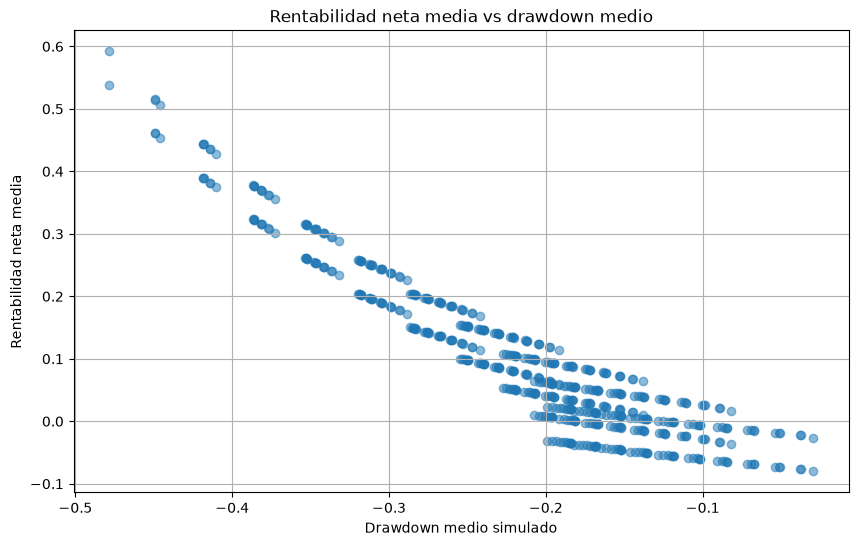

In [20]:
plt.figure(figsize=(10, 6))
plt.scatter(
    resumen_optimizacion["drawdown_medio"],
    resumen_optimizacion["rentabilidad_neta_media"],
    alpha=0.5
)

plt.title("Rentabilidad neta media vs drawdown medio")
plt.xlabel("Drawdown medio simulado")
plt.ylabel("Rentabilidad neta media")
plt.grid(True)
plt.show()

### Composición de las 10 mejores carteras

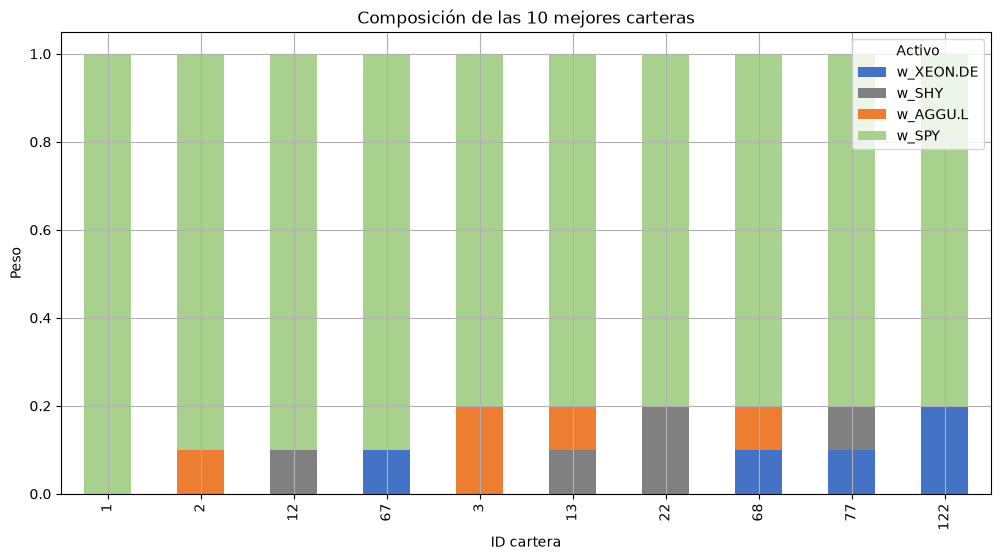

In [21]:
composicion_plot = composicion_top.set_index("id_cartera")[cols_pesos]

# Paleta "ejecutiva": azul, plomo, naranja y verde claro para el activo dominante (SPY)
colores_activos = [BLUE, "#808080", ORANGE, "#A9D18E"]  # XEON.DE, SHY, AGGU.L, SPY

composicion_plot.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6),
    color=colores_activos
)

plt.title("Composición de las 10 mejores carteras")
plt.xlabel("ID cartera")
plt.ylabel("Peso")
plt.legend(title="Activo")
plt.grid(True)
plt.show()


### Ilustración 2 - Riesgo histórico por perfil de cartera

Esta celda no existía en el notebook original: la Ilustración 2 de la memoria se había construido fuera del notebook a partir de `riesgo_historico_perfil_21d`. Se usa un único eje (en vez de doble eje) para no distorsionar la comparación de magnitudes entre volatilidad y drawdown, igual que en la imagen incrustada en el documento.

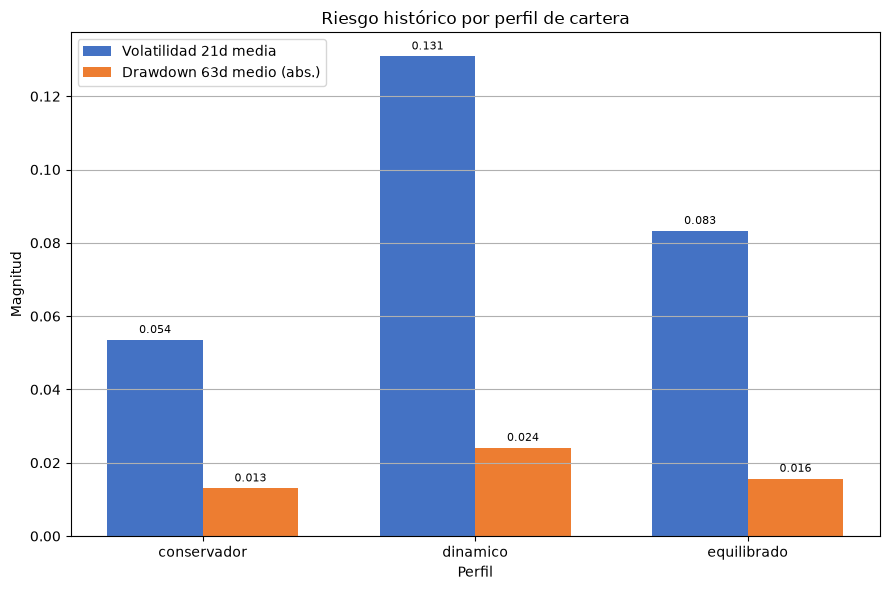

In [22]:
x = np.arange(len(riesgo_historico_perfil_21d))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 6))
ax.bar(x - width/2, riesgo_historico_perfil_21d["vol_21d_media"], width, label="Volatilidad 21d media", color=BLUE)
ax.bar(x + width/2, riesgo_historico_perfil_21d["drawdown_63d_abs_medio"], width, label="Drawdown 63d medio (abs.)", color=ORANGE)
etiquetar_barras(ax, fmt="{:.3f}", fontsize=8)

plt.xticks(x, riesgo_historico_perfil_21d["perfil"])
plt.xlabel("Perfil")
plt.ylabel("Magnitud")
plt.title("Riesgo histórico por perfil de cartera")
plt.legend(loc="upper left")
plt.grid(axis="y")
plt.tight_layout()
plt.show()


### Ilustración 3 - Distribución Monte Carlo del retorno simulado por perfil


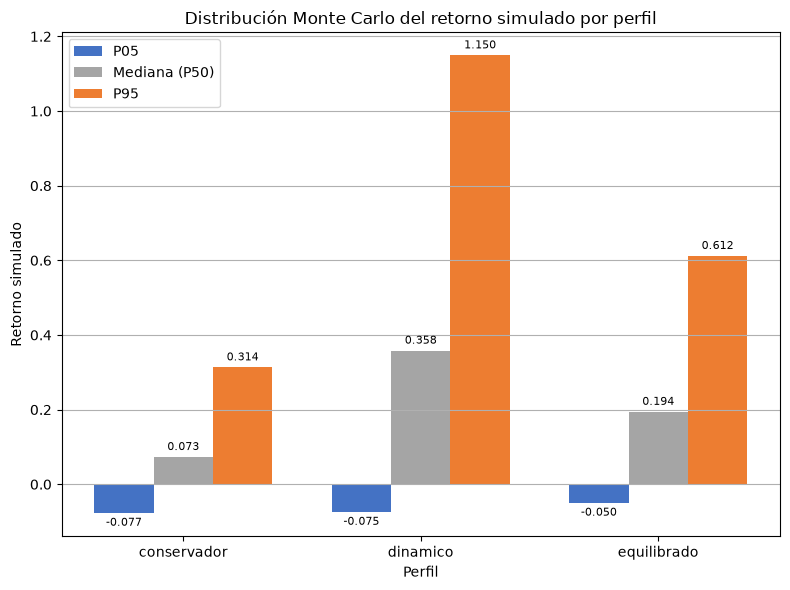

In [23]:
x = np.arange(len(mc_perfil))
width = 0.25

fig, ax = plt.subplots(figsize=(8, 6))
ax.bar(x - width, mc_perfil["retorno_p05"], width, label="P05", color=BLUE)
ax.bar(x, mc_perfil["retorno_p50"], width, label="Mediana (P50)", color="#A5A5A5")
ax.bar(x + width, mc_perfil["retorno_p95"], width, label="P95", color=ORANGE)
etiquetar_barras(ax, fmt="{:.3f}", fontsize=8)

plt.xticks(x, mc_perfil["perfil"])
plt.xlabel("Perfil")
plt.ylabel("Retorno simulado")
plt.title("Distribución Monte Carlo del retorno simulado por perfil")
plt.legend(loc="upper left")
plt.grid(axis="y")
plt.tight_layout()
plt.show()


### Ilustración 5 - LTV máximo medio por tipo de financiación

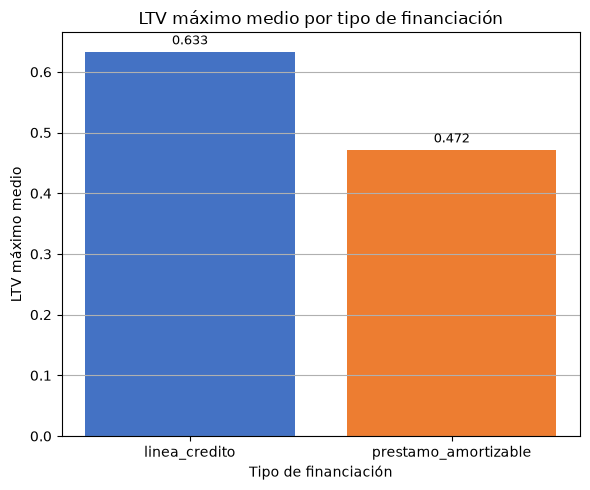

In [24]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.bar(comparativa_financiacion["tipo_financiacion"], comparativa_financiacion["ltv_maximo_medio"], color=PALETTE[:len(comparativa_financiacion)])
etiquetar_barras(ax, fmt="{:.3f}")
plt.title("LTV máximo medio por tipo de financiación")
plt.xlabel("Tipo de financiación")
plt.ylabel("LTV máximo medio")
plt.grid(axis="y")
plt.tight_layout()
plt.show()


### Ilustración 13 (nueva) - Validaciones finales del pipeline


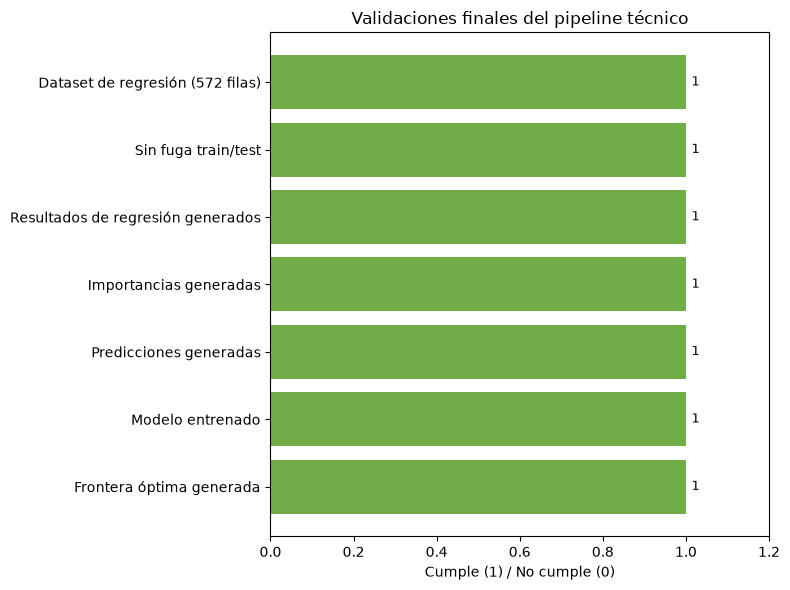

In [25]:
etiquetas = {
    "dataset_regresion_572_filas": "Dataset de regresión (572 filas)",
    "sin_fuga_entre_train_test": "Sin fuga train/test",
    "resultados_regresion_generados": "Resultados de regresión generados",
    "importancias_generadas": "Importancias generadas",
    "predicciones_generadas": "Predicciones generadas",
    "modelo_entrenado": "Modelo entrenado",
    "frontera_optima_generada": "Frontera óptima generada",
}

df_plot = tabla_validaciones_finales.copy()
df_plot["etiqueta"] = df_plot["validacion"].map(etiquetas).fillna(df_plot["validacion"])
colores = [PALETTE[2] if ok else PALETTE[1] for ok in df_plot["resultado"]]

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(df_plot["etiqueta"], df_plot["resultado"].astype(int), color=colores)
etiquetar_barras(ax, fmt="{:.0f}", horizontal=True)
plt.xlim(0, 1.2)
plt.xlabel("Cumple (1) / No cumple (0)")
plt.title("Validaciones finales del pipeline técnico")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()
